In [28]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, classification_report, 
                             confusion_matrix, recall_score, 
                             precision_score, f1_score, fbeta_score, average_precision_score)

import warnings
warnings.filterwarnings('ignore')

import optuna

In [2]:
df = pd.read_csv('Data.csv')
X = df.drop(columns=['loan_status'])
y = df['loan_status']

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Tách 85% còn lại thành Train và Validation (Tỷ lệ 15/85 ~ 17.6%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test: {X_test.shape}")

Train: (22814, 24)
Validation: (4873, 24)
Test: (4887, 24)


In [3]:
# Tính toán trọng số để xử lý mất cân bằng dữ liệu (Class Imbalance)
weight = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"Trọng số scale_pos_weight cho lớp vỡ nợ: {weight:.2f}\n")

Trọng số scale_pos_weight cho lớp vỡ nợ: 3.58



In [7]:
# SO SÁNH CÁC MÔ HÌNH
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    "XGBoost Baseline": xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, scale_pos_weight=weight, random_state=42, eval_metric='auc')
}

for name, model in models.items():
    # 1. Huấn luyện mô hình
    model.fit(X_train, y_train)
    
    # 2. Dự đoán xác suất để tính điểm AUC
    y_val_proba = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_val_proba)
    
    # 3. Dự đoán nhãn dán (0 hoặc 1 với ngưỡng mặc định 0.5) để tạo Ma trận
    y_val_pred = model.predict(X_val)
    cm = confusion_matrix(y_val, y_val_pred)
    
    # 4. In kết quả
    print(f"=== {name} ===")
    print(f"Validation AUC = {auc:.4f}")
    print(f"Confusion Matrix:\n{cm}\n")

=== Logistic Regression ===
Validation AUC = 0.8385
Confusion Matrix:
[[3648  162]
 [ 616  447]]

=== Random Forest ===
Validation AUC = 0.9256
Confusion Matrix:
[[3782   28]
 [ 332  731]]

=== XGBoost Baseline ===
Validation AUC = 0.9384
Confusion Matrix:
[[3656  154]
 [ 248  815]]



In [13]:
def objective(trial):
    # 1. Không gian tìm kiếm 
    param = {
        'n_estimators': 1000,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'scale_pos_weight': weight, # Vẫn giữ tỷ lệ phạt mất cân bằng
        'eval_metric': 'aucpr',
        'random_state': 42,
        'early_stopping_rounds': 30
    }
    
    # 2. Khởi tạo mô hình với tham số thử nghiệm
    model = xgb.XGBClassifier(**param)
    
    # 3. Huấn luyện có kiểm soát bằng tập Validation
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    # 4. Trả về điểm AUC để Optuna đánh giá
    return model.best_score

# 5. Kích hoạt quá trình tìm kiếm 
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

print(f"Best Validation AUC-PR : {study.best_value:.4f}")
print(f"Optimal parameter set: {study.best_params}")


# Lấy  mô hình tốt nhất 
best_xgb_model = xgb.XGBClassifier(
    n_estimators=1000,
    **study.best_params,
    scale_pos_weight=weight,
    random_state=42
)

# Lấy mô hình tốt nhất 
best_xgb_model = xgb.XGBClassifier(
    n_estimators=1000,
    **study.best_params,
    scale_pos_weight=weight,
    random_state=42,
    early_stopping_rounds=30 # Bật lại cơ chế dừng sớm
)

# Đưa tập Validation vào để canh chừng lúc huấn luyện cuối
best_xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

[I 2026-05-19 22:14:47,658] A new study created in memory with name: no-name-4d2f6cc5-5410-4628-aaa8-3b3c186c71c7
[I 2026-05-19 22:14:49,903] Trial 0 finished with value: 0.8895973896325158 and parameters: {'learning_rate': 0.024303145088913656, 'max_depth': 4, 'min_child_weight': 2, 'subsample': 0.6853288555295283, 'colsample_bytree': 0.6767476768750418}. Best is trial 0 with value: 0.8895973896325158.
[I 2026-05-19 22:14:50,278] Trial 1 finished with value: 0.8845267582748279 and parameters: {'learning_rate': 0.12630381700067114, 'max_depth': 6, 'min_child_weight': 3, 'subsample': 0.5429337392937488, 'colsample_bytree': 0.8760391961243877}. Best is trial 0 with value: 0.8895973896325158.
[I 2026-05-19 22:14:50,651] Trial 2 finished with value: 0.8913417366145313 and parameters: {'learning_rate': 0.24050129212781404, 'max_depth': 4, 'min_child_weight': 6, 'subsample': 0.8588828739148038, 'colsample_bytree': 0.8927457752765604}. Best is trial 2 with value: 0.8913417366145313.
[I 2026-0

Best Validation AUC-PR : 0.8994
Optimal parameter set: {'learning_rate': 0.036181195182159315, 'max_depth': 7, 'min_child_weight': 3, 'subsample': 0.9572364122875016, 'colsample_bytree': 0.5040690696295872}


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.5040690696295872
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",30
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import lo

=> Thuật toán tự động chốt Ngưỡng tối ưu: 0.25
=> Tại ngưỡng này, mô hình đạt được:
   - F2-Score  : 0.8135 (Chỉ số tối ưu chính)
   - Recall    : 0.8627 (Tỷ lệ bắt nợ xấu)
   - Precision : 0.6626 (Độ chính xác khi cảnh báo)


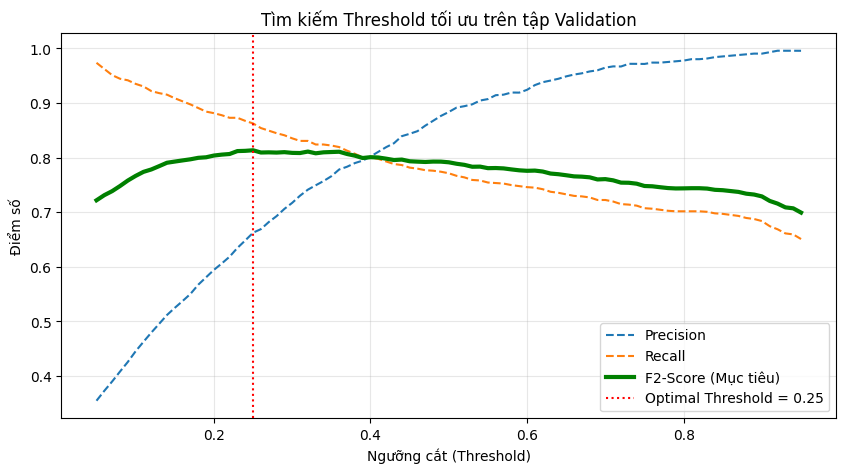

In [26]:
# Lấy xác suất dự đoán từ mô hình XGBoost tốt nhất
# Dự đoán trên tập Validation để tìm ngưỡng
y_val_proba = best_xgb_model.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.05, 0.96, 0.01)

best_threshold = 0.5
best_f2_score = 0
best_metrics = {}

precisions = []
recalls = []
f2_scores = []

# Tìm Threshold tốt nhất
for thresh in thresholds:
    # Nếu xác suất >= ngưỡng đang xét -> Gắn nhãn 1 (Vỡ nợ)
    y_val_pred = (y_val_proba >= thresh).astype(int)
    
    # Tính toán các chỉ số
    # zero_division=0 để tránh cảnh báo lỗi chia cho 0 nếu mô hình không đoán ra nhãn 1 nào
    prec = precision_score(y_val, y_val_pred, zero_division=0) 
    rec = recall_score(y_val, y_val_pred)
    
    # Dùng fbeta_score với beta=2 để tính F2-Score
    f2 = fbeta_score(y_val, y_val_pred, beta=2)
    
    precisions.append(prec)
    recalls.append(rec)
    f2_scores.append(f2)
    
    # Lưu lại ngưỡng mang lại điểm F2 cao nhất
    if f2 > best_f2_score:
        best_f2_score = f2
        best_threshold = thresh
        best_metrics = {'Precision': prec, 'Recall': rec, 'F1': f1_score(y_val, y_val_pred)}

print(f"=> Thuật toán tự động chốt Ngưỡng tối ưu: {best_threshold:.2f}")
print(f"=> Tại ngưỡng này, mô hình đạt được:")
print(f"   - F2-Score  : {best_f2_score:.4f} (Chỉ số tối ưu chính)")
print(f"   - Recall    : {best_metrics['Recall']:.4f} (Tỷ lệ bắt nợ xấu)")
print(f"   - Precision : {best_metrics['Precision']:.4f} (Độ chính xác khi cảnh báo)")

plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions, label='Precision', linestyle='--')
plt.plot(thresholds, recalls, label='Recall', linestyle='--')
plt.plot(thresholds, f2_scores, label='F2-Score (Mục tiêu)', linewidth=3, color='green')

# Vẽ đường gióng thẳng đứng tại Threshold tốt nhất
plt.axvline(x=best_threshold, color='red', linestyle=':', 
            label=f'Optimal Threshold = {best_threshold:.2f}')

plt.title('Tìm kiếm Threshold tối ưu trên tập Validation')
plt.xlabel('Ngưỡng cắt (Threshold)')
plt.ylabel('Điểm số')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

   - ROC-AUC Score: 0.9426 
   - PR-AUC Score: 0.8950 
   - F2-Score: 0.8056
   - Recall: 0.8508

Classification Report: 

              precision    recall  f1-score   support

           0       0.95      0.88      0.92      3821
           1       0.66      0.85      0.75      1066

    accuracy                           0.87      4887
   macro avg       0.81      0.87      0.83      4887
weighted avg       0.89      0.87      0.88      4887



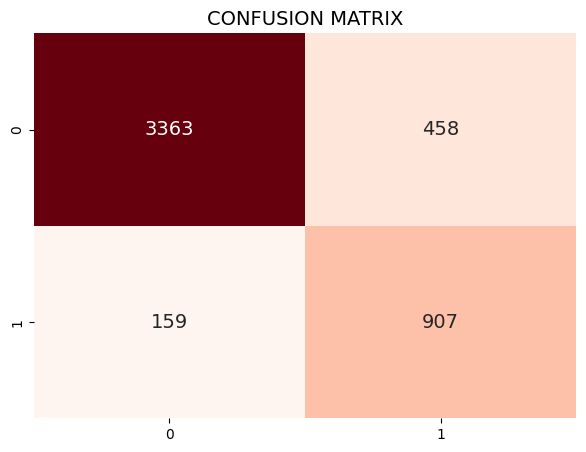

In [43]:
y_test_proba = best_xgb_model.predict_proba(X_test)[:, 1]

# Áp dụng Ngưỡng cắt (Threshold)  đã tìm được 
final_threshold = best_threshold 
y_test_pred_final = (y_test_proba >= final_threshold).astype(int)

# Tính toán các điểm số cốt lõi
test_roc_auc = roc_auc_score(y_test, y_test_proba)
test_pr_auc = average_precision_score(y_test, y_test_proba)
test_f2 = fbeta_score(y_test, y_test_pred_final, beta=2)
test_recall = recall_score(y_test, y_test_pred_final)

print(f"   - ROC-AUC Score: {test_roc_auc:.4f} ")
print(f"   - PR-AUC Score: {test_pr_auc:.4f} ")
print(f"   - F2-Score: {test_f2:.4f}")
print(f"   - Recall: {test_recall:.4f}\n")

print("Classification Report: \n" )
print(classification_report(y_test, y_test_pred_final))

cm_final = confusion_matrix(y_test, y_test_pred_final)
plt.figure(figsize=(7,5))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=['0', '1'],
            yticklabels=['0', '1'],
            annot_kws={"size": 14}) 

plt.title(f'CONFUSION MATRIX', fontsize=14)
plt.show()

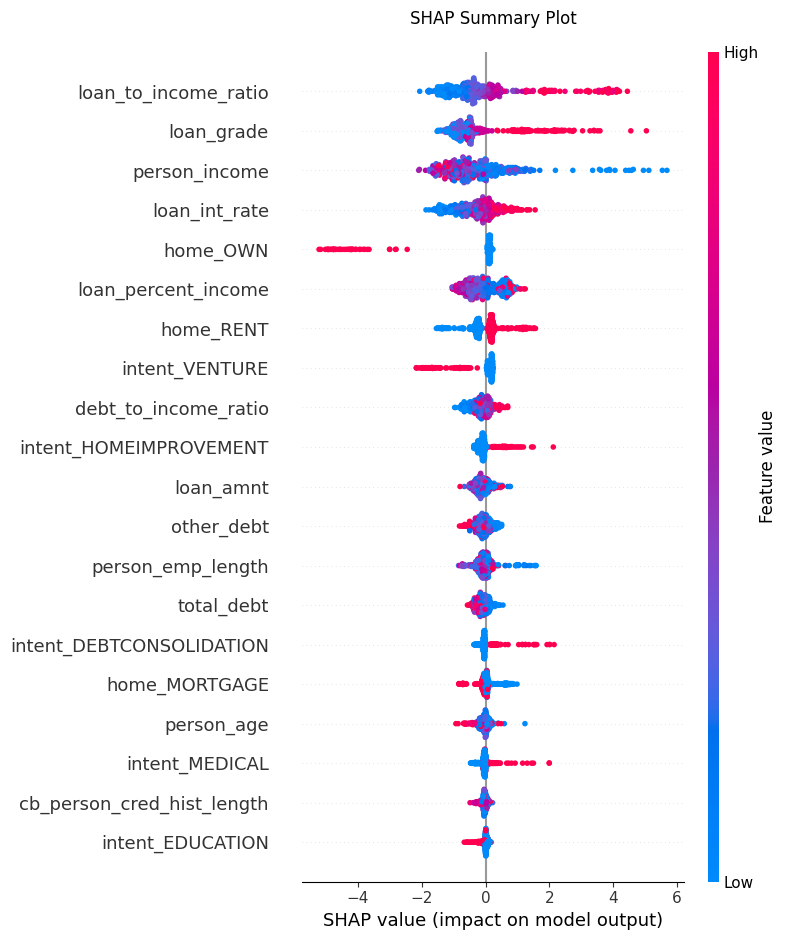

In [45]:
explainer = shap.TreeExplainer(best_xgb_model)

X_test_sample = X_test.sample(n=min(500, len(X_test)), random_state=42)

shap_values = explainer.shap_values(X_test_sample)

plt.figure(figsize=(10, 6))
plt.title('SHAP Summary Plot', pad=20)
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.show()

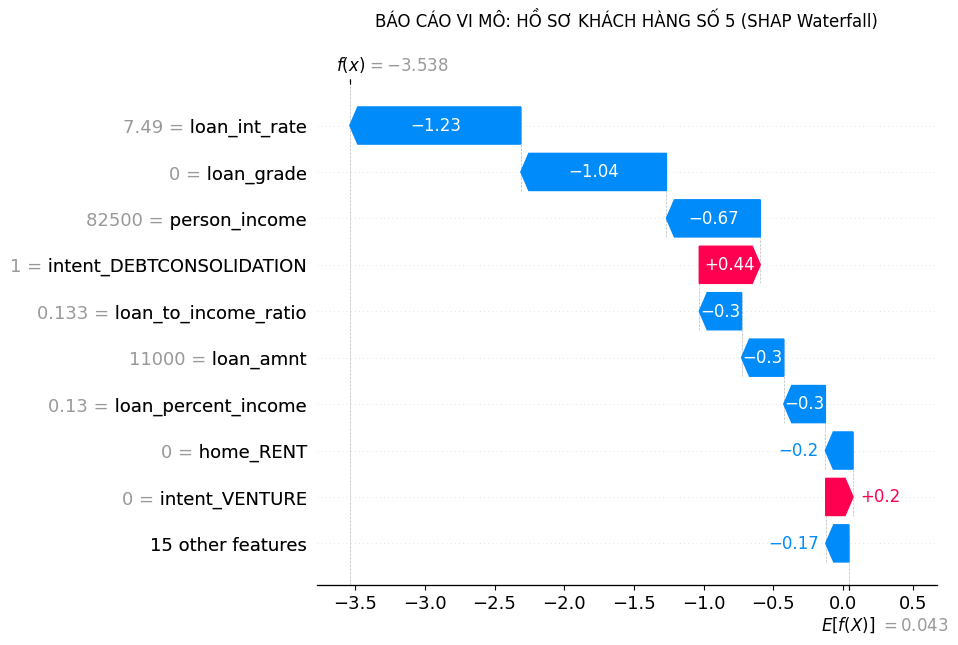

In [ ]:
# Giả sử lấy khách hàng ở dòng thứ 5 (index = 5)
customer_index = 5 
single_customer = X_test.iloc[[customer_index]]

shap_values_single = explainer(single_customer)

plt.figure(figsize=(8, 4))
plt.title(f'BÁO CÁO VI MÔ: HỒ SƠ KHÁCH HÀNG SỐ {customer_index} (SHAP Waterfall)', pad=20)

shap.plots.waterfall(shap_values_single[0], max_display=10, show=False)
plt.show()